# Kyrgyzstan Education Statistics — Rich Visualisation Notebook

10 publication-quality charts covering literacy, student enrollment, budget trends, country breakdown, and regression.

Datasets: `literacy.csv` · `students_cis.csv` · `students_non_cis.csv` · `education_budget.csv`

## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

BLUE   = '#2563EB'
ORANGE = '#EA580C'
GREEN  = '#16A34A'
PURPLE = '#7C3AED'
RED    = '#DC2626'
GRAY   = '#6B7280'

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})
print('Setup complete.')

Setup complete.


In [3]:
literacy_raw  = pd.read_csv('../data/literacy.csv',        encoding='utf-8-sig')
cis_raw       = pd.read_csv('../data/students_cis.csv',     encoding='utf-8-sig')
non_cis_raw   = pd.read_csv('../data/students_non_cis.csv', encoding='utf-8-sig')
budget_raw    = pd.read_csv('../data/education_budget.csv', encoding='utf-8-sig')

year_cols = [str(y) for y in range(2010, 2025)]

# Literacy
literacy = literacy_raw[['Items','1989','1999','2009','2022']].copy()
literacy.columns = ['Category','1989','1999','2009','2022']
literacy['Category'] = literacy['Category'].str.strip()
for col in ['1989','1999','2009','2022']:
    literacy[col] = pd.to_numeric(literacy[col], errors='coerce')
literacy_clean = literacy[literacy['Category'].notna() & (literacy['Category']!='') & literacy['1989'].notna()].copy()

# Students
def extract_by_country(df, group_label):
    en_col = df.columns[2]
    skip = {'total','ncluding:','including:','','nan'}
    rows = []
    for _, row in df.iterrows():
        name = str(row[en_col]).strip()
        if name.lower() in skip or 'Including' in name:
            continue
        vals = pd.to_numeric(pd.Series([row[y] for y in year_cols]), errors='coerce').values
        rows.append({'Country': name, 'Group': group_label, **dict(zip(year_cols, vals))})
    return pd.DataFrame(rows)

def extract_totals(df):
    en_col = df.columns[2]
    mask = df[en_col].astype(str).str.strip().str.lower().isin(['total'])
    row = df[mask].iloc[0]
    return pd.to_numeric(row[year_cols], errors='coerce')

cis_countries     = extract_by_country(cis_raw, 'CIS')
non_cis_countries = extract_by_country(non_cis_raw, 'Non-CIS')
countries_df      = pd.concat([cis_countries, non_cis_countries], ignore_index=True)

cis_total     = extract_totals(cis_raw)
non_cis_total = extract_totals(non_cis_raw)
students_df   = pd.DataFrame({'Year':[int(y) for y in year_cols],
                              'CIS':cis_total.values, 'Non_CIS':non_cis_total.values})
students_df['Total']      = students_df['CIS'] + students_df['Non_CIS']
students_df['CIS_pct']    = students_df['CIS'] / students_df['Total'] * 100
students_df['NonCIS_pct'] = students_df['Non_CIS'] / students_df['Total'] * 100

# Budget
budget = budget_raw.copy()
en_col_b = budget.columns[2]
budget[en_col_b] = budget[en_col_b].astype(str).str.strip()
b_years = [str(y) for y in range(2001, 2025)]
for col in b_years:
    if col in budget.columns:
        budget[col] = pd.to_numeric(budget[col], errors='coerce')

def get_budget_row(kw):
    mask = budget[en_col_b].str.lower().str.contains(kw, na=False)
    return budget[mask].iloc[0][b_years].astype(float) if mask.any() else pd.Series([np.nan]*len(b_years), index=b_years)

budget_ts = pd.DataFrame({'Year':[int(y) for y in b_years],
    'Total_mln_som': get_budget_row('total').values,
    'Preschool':     get_budget_row('pre-school').values,
    'Higher':        get_budget_row('higher').values,
})
merged = students_df.merge(budget_ts[budget_ts['Year']>=2010][['Year','Total_mln_som']], on='Year')
print('All data loaded and cleaned.')

All data loaded and cleaned.


## 2. Figure 1 — Education Attainment by Level (Census Years)

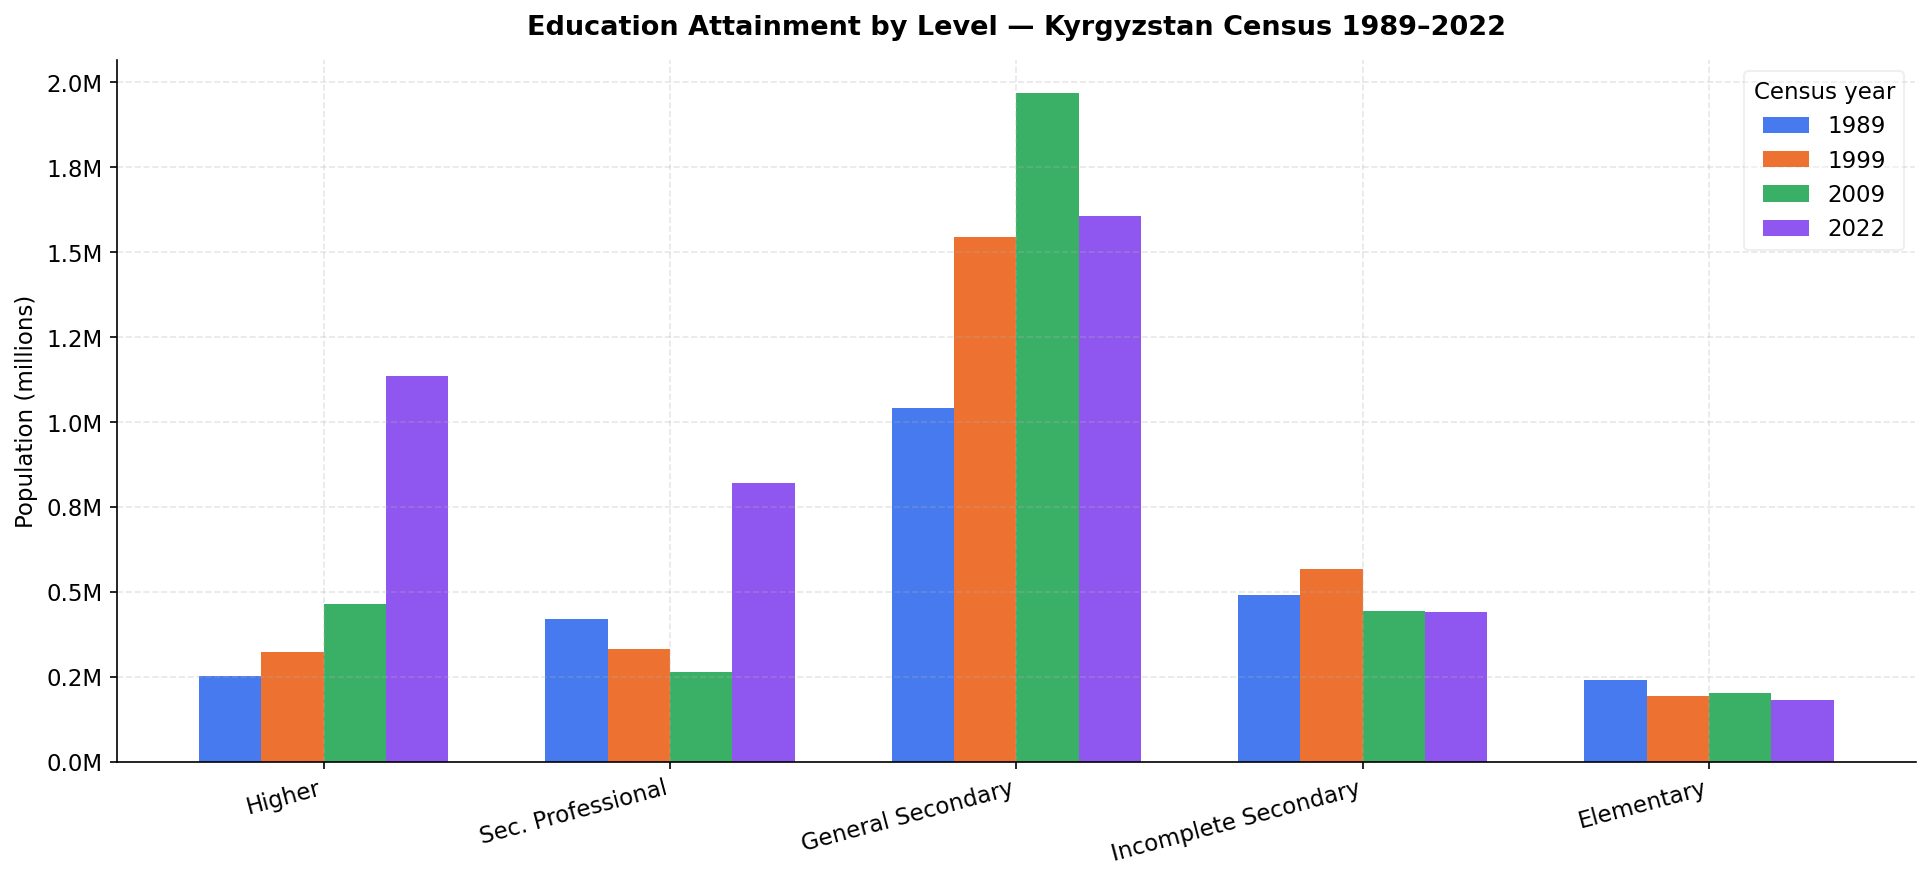

Fig 1 saved.


In [4]:
edu_cats = [
    'Higher professional education',
    'Secondary professional education',
    'Secondary general education1',
    'Incomplete secondary education',
    'Elementary education',
]
short_labels = ['Higher','Sec. Professional','General Secondary','Incomplete Secondary','Elementary']
census_years = ['1989','1999','2009','2022']

plot_data = literacy_clean[literacy_clean['Category'].isin(edu_cats)].copy()
plot_data = plot_data.set_index('Category')[census_years]
plot_data.index = short_labels

x = np.arange(len(short_labels))
width = 0.18
colors = [BLUE, ORANGE, GREEN, PURPLE]

fig, ax = plt.subplots(figsize=(13, 6))
for i, (yr, col) in enumerate(zip(census_years, colors)):
    bars = ax.bar(x + i*width - 1.5*width, plot_data[yr]/1e6, width, label=yr, color=col, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=15, ha='right')
ax.set_ylabel('Population (millions)')
ax.set_title('Education Attainment by Level — Kyrgyzstan Census 1989–2022', fontsize=13, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.1f}M'))
ax.legend(title='Census year', framealpha=0.3)
plt.tight_layout()
plt.savefig('../photo/fig1_education_attainment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 1 saved.')

## 3. Figure 2 — Illiteracy vs Higher Education Trend

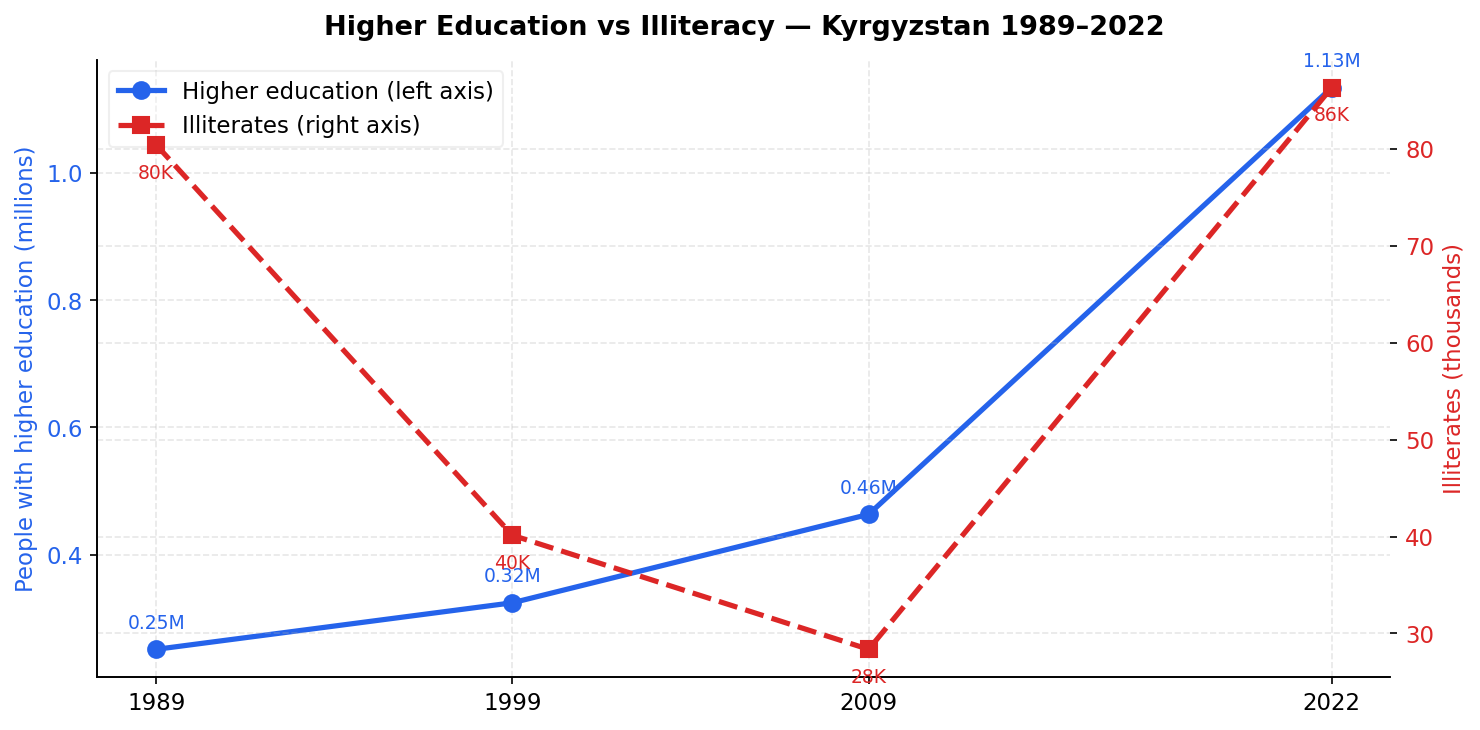

Fig 2 saved.


In [5]:
census_yrs = [1989,1999,2009,2022]
higher_row = literacy_clean[literacy_clean['Category'].str.contains('Higher professional', na=False)].iloc[0]
illit_row  = literacy_clean[literacy_clean['Category'].str.lower().str.strip()=='illiterates'].iloc[0]
higher_vals = [higher_row[str(y)] for y in census_yrs]
illit_vals  = [illit_row[str(y)]  for y in census_yrs]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

l1, = ax1.plot(census_yrs, [v/1e6 for v in higher_vals], 'o-', color=BLUE, linewidth=2.5, markersize=8, label='Higher education (left axis)')
l2, = ax2.plot(census_yrs, [v/1e3 for v in illit_vals],  's--', color=RED,  linewidth=2.5, markersize=8, label='Illiterates (right axis)')

ax1.set_ylabel('People with higher education (millions)', color=BLUE)
ax2.set_ylabel('Illiterates (thousands)', color=RED)
ax1.tick_params(axis='y', labelcolor=BLUE)
ax2.tick_params(axis='y', labelcolor=RED)
ax1.set_xticks(census_yrs)
ax1.set_title('Higher Education vs Illiteracy — Kyrgyzstan 1989–2022', fontsize=13, fontweight='bold', pad=12)

for yr, hv, iv in zip(census_yrs, higher_vals, illit_vals):
    ax1.annotate(f'{hv/1e6:.2f}M', (yr, hv/1e6), textcoords='offset points', xytext=(0,10), ha='center', fontsize=9, color=BLUE)
    ax2.annotate(f'{iv/1e3:.0f}K',  (yr, iv/1e3),  textcoords='offset points', xytext=(0,-16), ha='center', fontsize=9, color=RED)

ax1.legend(handles=[l1,l2], loc='upper left', framealpha=0.3)
plt.tight_layout()
plt.savefig('../photo/fig2_literacy_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 2 saved.')

## 4. Figure 3 — International Students Stacked Area

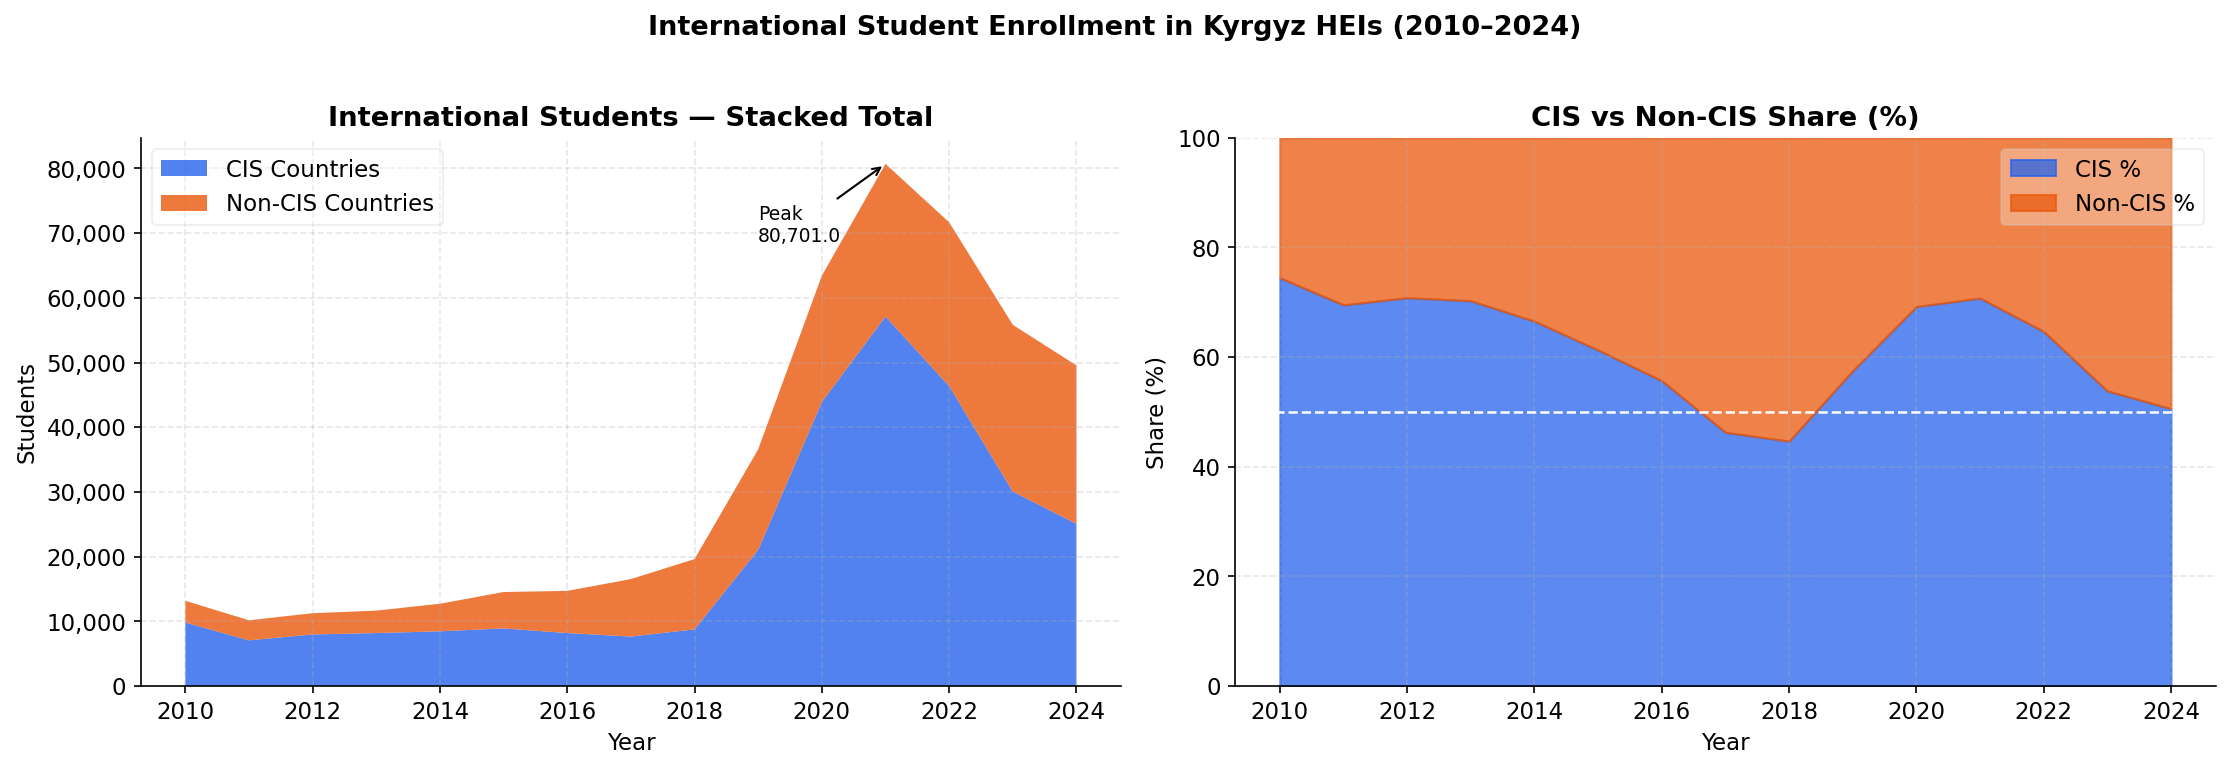

Fig 3 saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: stacked area
ax = axes[0]
ax.stackplot(students_df['Year'], students_df['CIS'], students_df['Non_CIS'],
             labels=['CIS Countries','Non-CIS Countries'],
             colors=[BLUE, ORANGE], alpha=0.80)
ax.set_title('International Students — Stacked Total', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Students')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend(loc='upper left', framealpha=0.3)
peak_yr = students_df.loc[students_df['Total'].idxmax(), 'Year']
peak_v  = students_df['Total'].max()
ax.annotate(f'Peak\n{peak_v:,}', xy=(peak_yr, peak_v), xytext=(peak_yr-2, peak_v*0.85),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

# Right: % share
ax2 = axes[1]
ax2.fill_between(students_df['Year'], students_df['CIS_pct'], label='CIS %', color=BLUE, alpha=0.75)
ax2.fill_between(students_df['Year'], students_df['CIS_pct'], 100, label='Non-CIS %', color=ORANGE, alpha=0.75)
ax2.axhline(50, color='white', linewidth=1.2, linestyle='--')
ax2.set_ylim(0,100)
ax2.set_title('CIS vs Non-CIS Share (%)', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Share (%)')
ax2.legend(loc='upper right', framealpha=0.3)

plt.suptitle('International Student Enrollment in Kyrgyz HEIs (2010–2024)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../photo/fig3_enrollment_area.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 3 saved.')

## 5. Figure 4 — Top 10 Countries Bar Chart (Total 2010–2024)

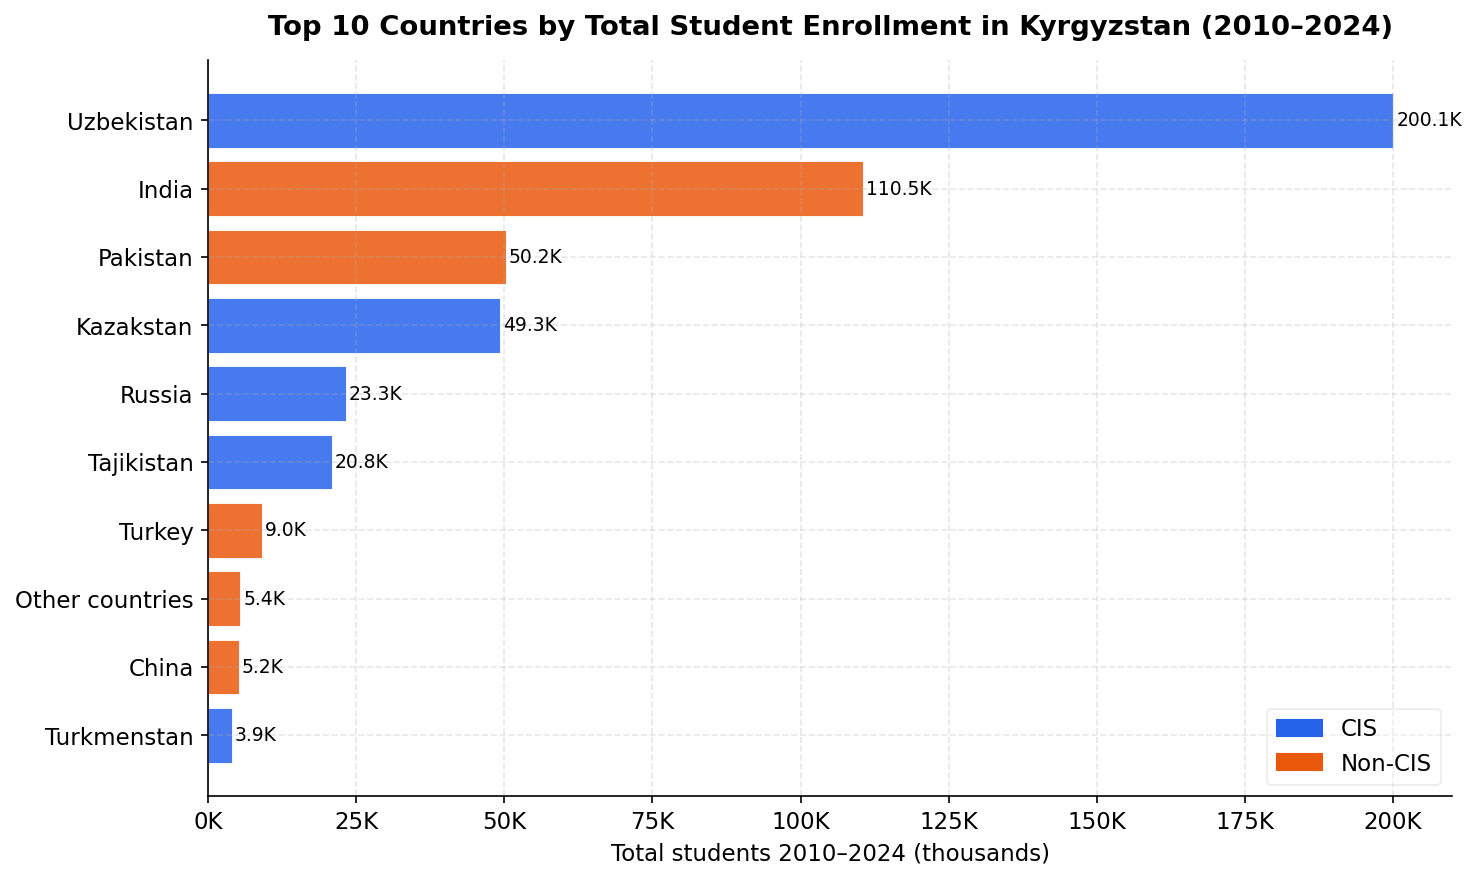

Fig 4 saved.


In [7]:
totals = countries_df.copy()
totals['Total'] = totals[year_cols].sum(axis=1)
top10 = totals.sort_values('Total', ascending=True).tail(10)

colors_bar = [BLUE if g=='CIS' else ORANGE for g in top10['Group']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['Country'], top10['Total']/1e3, color=colors_bar, alpha=0.85, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, top10['Total']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val/1e3:.1f}K', va='center', fontsize=9)

patch_cis    = mpatches.Patch(color=BLUE,   label='CIS')
patch_noncis = mpatches.Patch(color=ORANGE, label='Non-CIS')
ax.legend(handles=[patch_cis, patch_noncis], framealpha=0.3)
ax.set_xlabel('Total students 2010–2024 (thousands)')
ax.set_title('Top 10 Countries by Total Student Enrollment in Kyrgyzstan (2010–2024)', fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}K'))
plt.tight_layout()
plt.savefig('fig4_top10_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 4 saved.')

## 6. Figure 5 — Per-Country Trend Lines (Top 6)

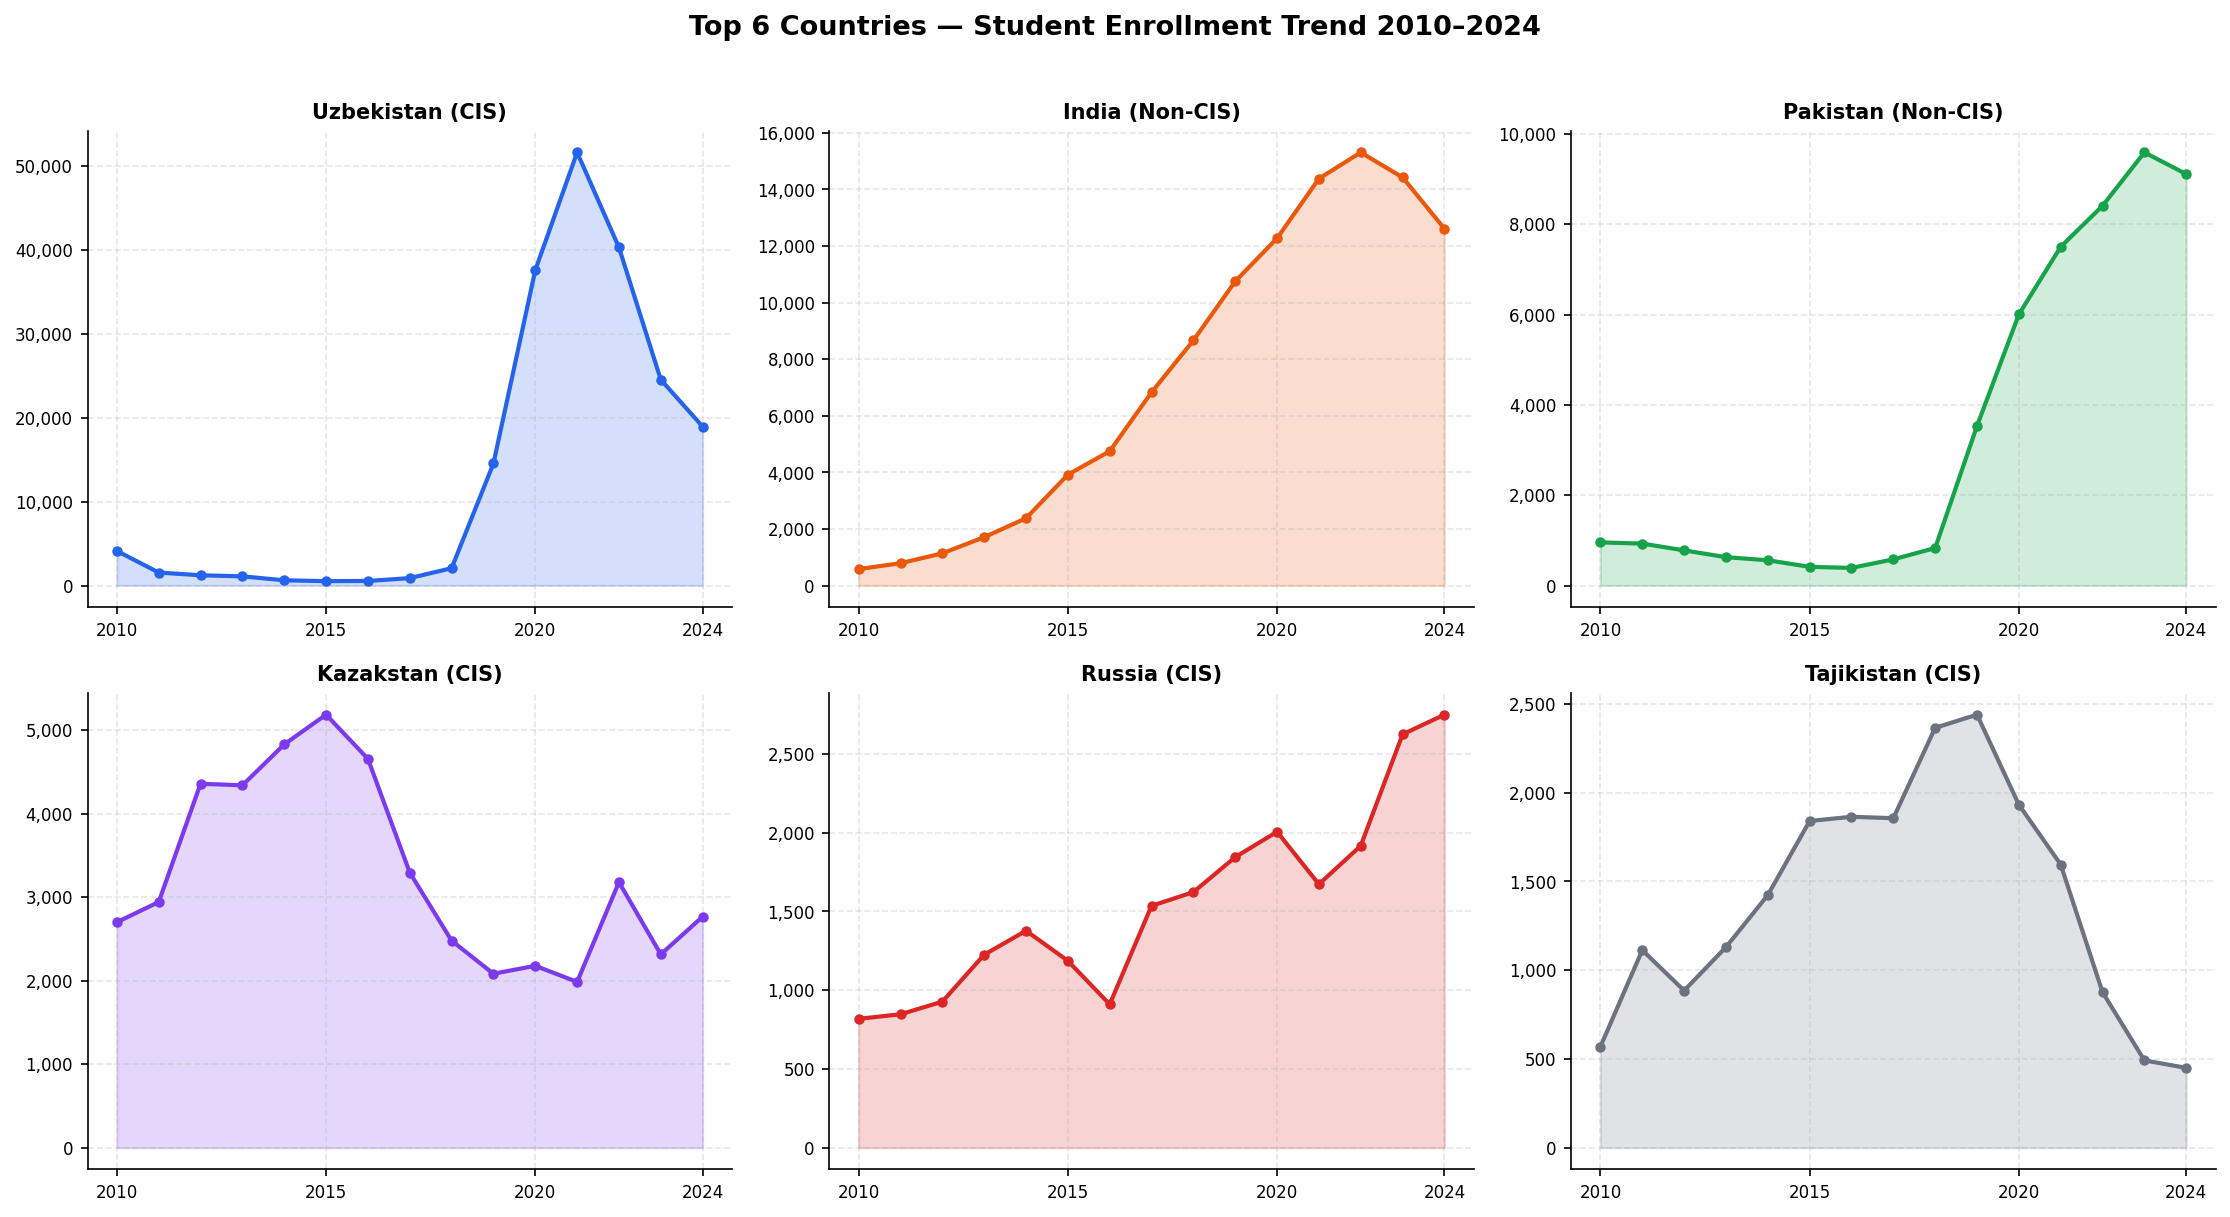

Fig 5 saved.


In [8]:
totals2 = countries_df.copy()
totals2['Total'] = totals2[year_cols].sum(axis=1)
top6 = totals2.sort_values('Total', ascending=False).head(6)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
palette = [BLUE, ORANGE, GREEN, PURPLE, RED, GRAY]

for ax, (_, row), col in zip(axes.flat, top6.iterrows(), palette):
    vals = pd.to_numeric(pd.Series([row[y] for y in year_cols]), errors='coerce')
    yrs_int = [int(y) for y in year_cols]
    ax.fill_between(yrs_int, vals, alpha=0.2, color=col)
    ax.plot(yrs_int, vals, 'o-', color=col, linewidth=2, markersize=4)
    ax.set_title(f"{row['Country']} ({row['Group']})", fontweight='bold', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))
    ax.set_xticks([2010,2015,2020,2024])
    ax.tick_params(labelsize=8)

plt.suptitle('Top 6 Countries — Student Enrollment Trend 2010–2024', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../photo/fig5_top6_country_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 5 saved.')

## 7. Figure 6 — Education Budget Over Time

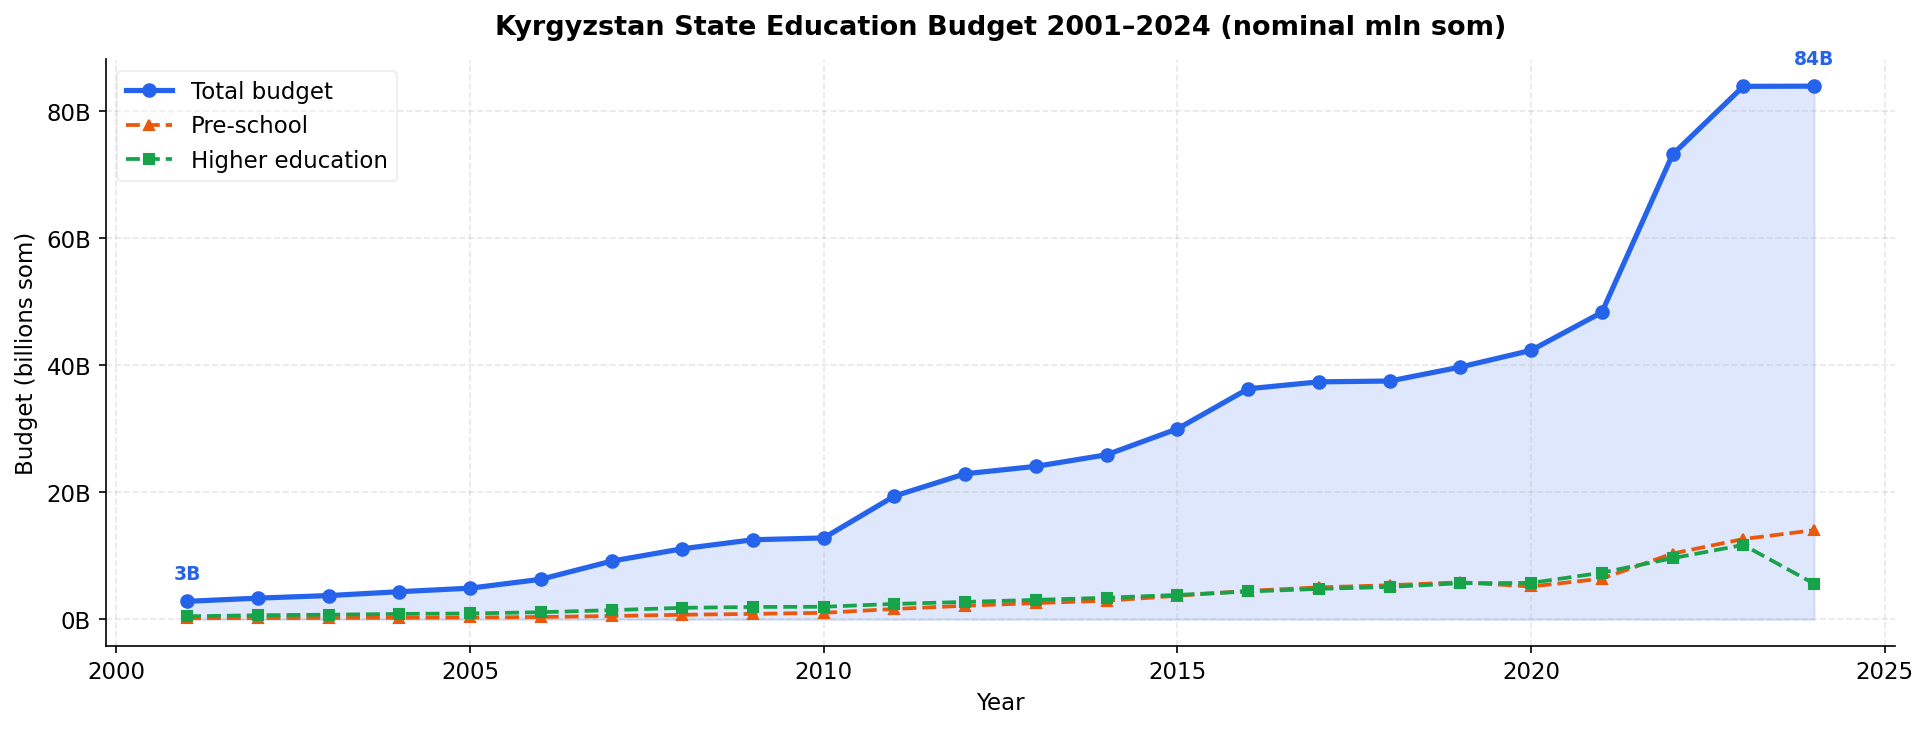

Fig 6 saved.


In [9]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(budget_ts['Year'], budget_ts['Total_mln_som']/1e3, alpha=0.15, color=BLUE)
ax.plot(budget_ts['Year'], budget_ts['Total_mln_som']/1e3, 'o-', color=BLUE, linewidth=2.5, label='Total budget')
ax.plot(budget_ts['Year'], budget_ts['Preschool']/1e3,     '^--', color=ORANGE, linewidth=1.8, markersize=5, label='Pre-school')
ax.plot(budget_ts['Year'], budget_ts['Higher']/1e3,         's--', color=GREEN,  linewidth=1.8, markersize=5, label='Higher education')

# Annotate first and last
for yr_i, yr in [(0, budget_ts['Year'].iloc[0]), (-1, budget_ts['Year'].iloc[-1])]:
    v = budget_ts['Total_mln_som'].iloc[yr_i]
    ax.annotate(f'{v/1e3:.0f}B', xy=(yr, v/1e3), xytext=(yr, v/1e3 + budget_ts['Total_mln_som'].max()*0.04/1e3),
                ha='center', fontsize=9, color=BLUE, fontweight='bold')

ax.set_xlabel('Year')
ax.set_ylabel('Budget (billions som)')
ax.set_title('Kyrgyzstan State Education Budget 2001–2024 (nominal mln som)', fontsize=13, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}B'))
ax.legend(framealpha=0.3)
plt.tight_layout()
plt.savefig('fig6_budget_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 6 saved.')

## 8. Figure 7 — Correlation Heatmap

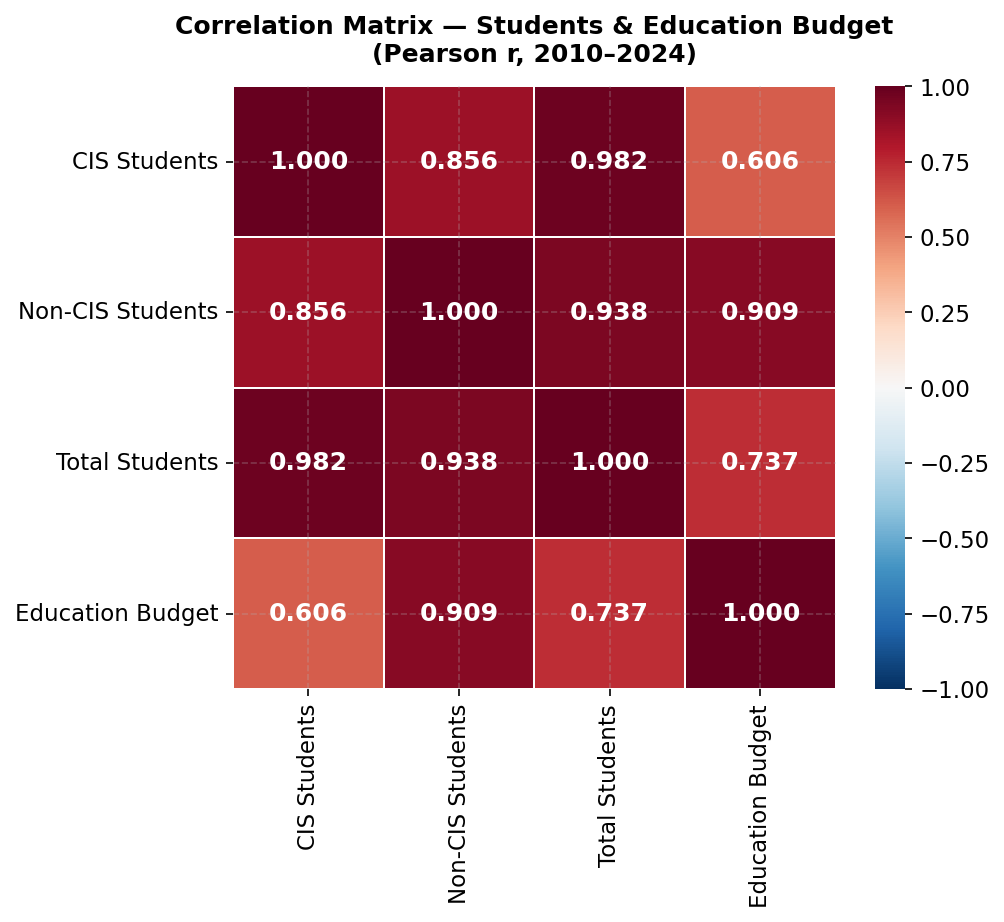

Fig 7 saved.


In [10]:
corr_df = merged[['CIS','Non_CIS','Total','Total_mln_som']].copy()
corr_df.columns = ['CIS Students','Non-CIS Students','Total Students','Education Budget']

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool), k=1)
sns.heatmap(corr_df.corr(), annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            linewidths=0.8, ax=ax, square=True, vmin=-1, vmax=1,
            annot_kws={'size':12,'weight':'bold'})
ax.set_title('Correlation Matrix — Students & Education Budget\n(Pearson r, 2010–2024)', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../photo/fig7_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 7 saved.')

## 9. Figure 8 — Regression: Budget → Total Students

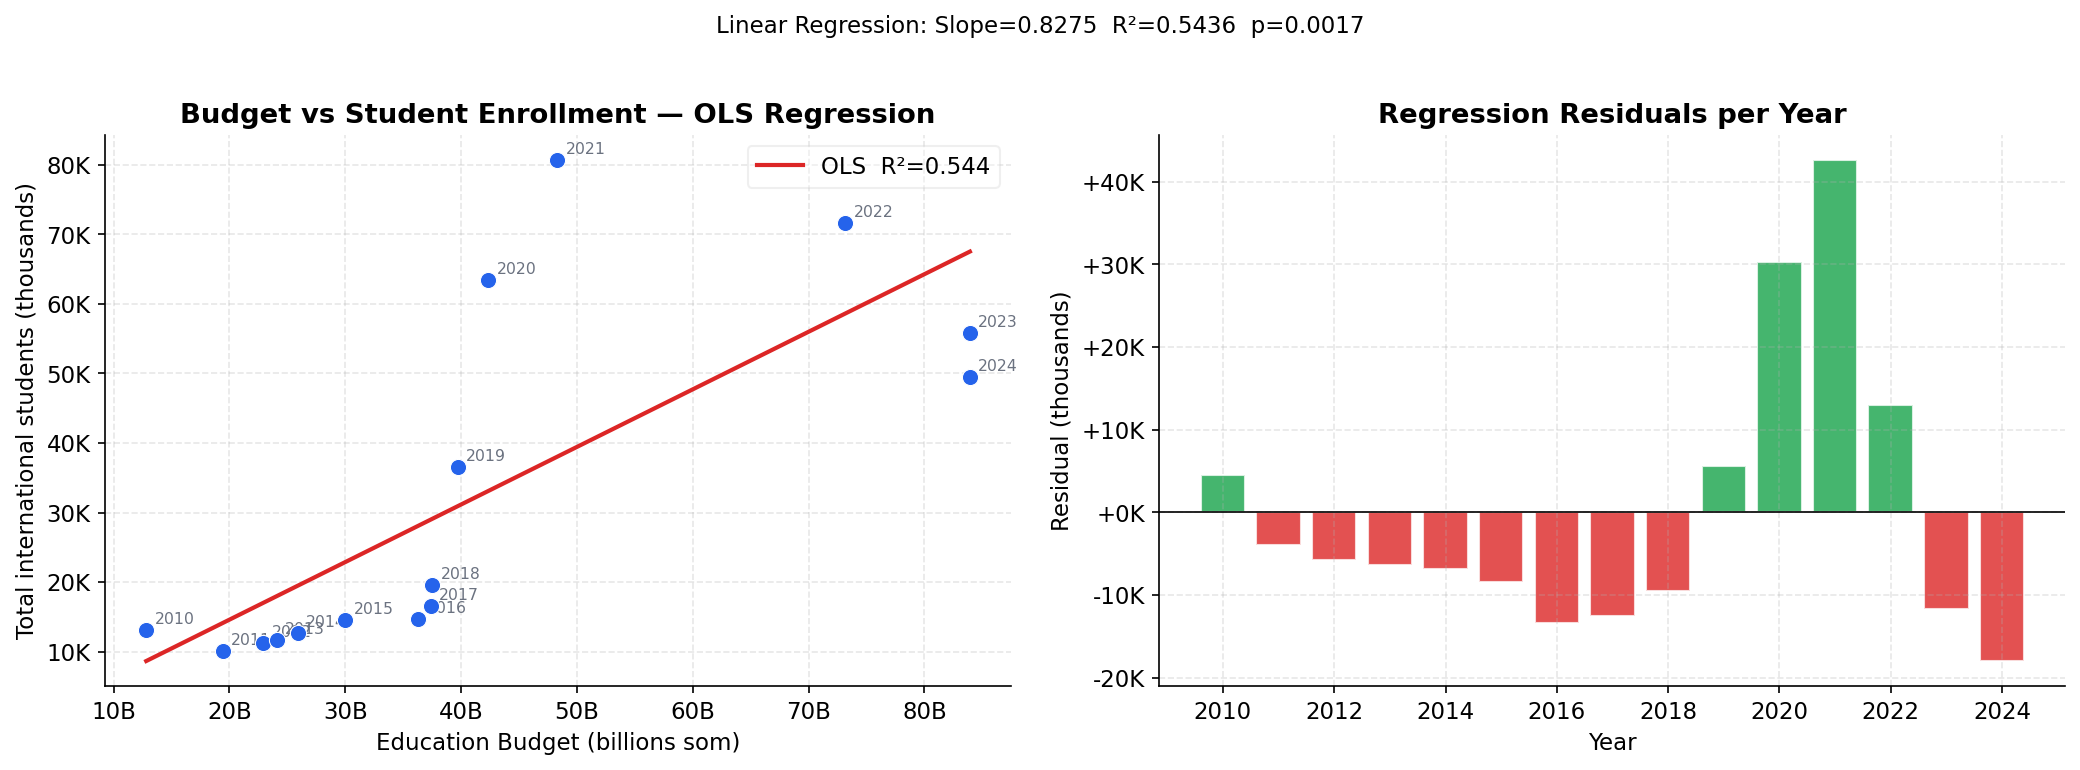

Fig 8 saved.


In [11]:
X = merged['Total_mln_som'].values
Y = merged['Total'].values
slope, intercept, r_value, p_value, std_err = linregress(X, Y)
X_line = np.linspace(X.min(), X.max(), 200)
Y_line = slope * X_line + intercept
Y_pred = slope * X + intercept
residuals = Y - Y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter + regression
ax = axes[0]
sc = ax.scatter(X/1e3, Y/1e3, color=BLUE, s=60, zorder=5, edgecolor='white', linewidth=0.5)
ax.plot(X_line/1e3, Y_line/1e3, color=RED, linewidth=2, label=f'OLS  R²={r_value**2:.3f}')
for xi, yi, yr in zip(X, Y, merged['Year']):
    ax.annotate(str(yr), (xi/1e3, yi/1e3), fontsize=7.5, color=GRAY,
                textcoords='offset points', xytext=(4,3))
ax.set_xlabel('Education Budget (billions som)')
ax.set_ylabel('Total international students (thousands)')
ax.set_title('Budget vs Student Enrollment — OLS Regression', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}B'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}K'))
ax.legend(framealpha=0.3)

# Residuals
ax2 = axes[1]
colors_r = [GREEN if r>=0 else RED for r in residuals]
ax2.bar(merged['Year'], residuals/1e3, color=colors_r, alpha=0.8, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Year')
ax2.set_ylabel('Residual (thousands)')
ax2.set_title('Regression Residuals per Year', fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:+.0f}K'))

plt.suptitle(f'Linear Regression: Slope={slope:.4f}  R²={r_value**2:.4f}  p={p_value:.4f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('../photo/fig8_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 8 saved.')

## 10. Figure 9 — Boxplot: CIS vs Non-CIS Annual Growth Rates

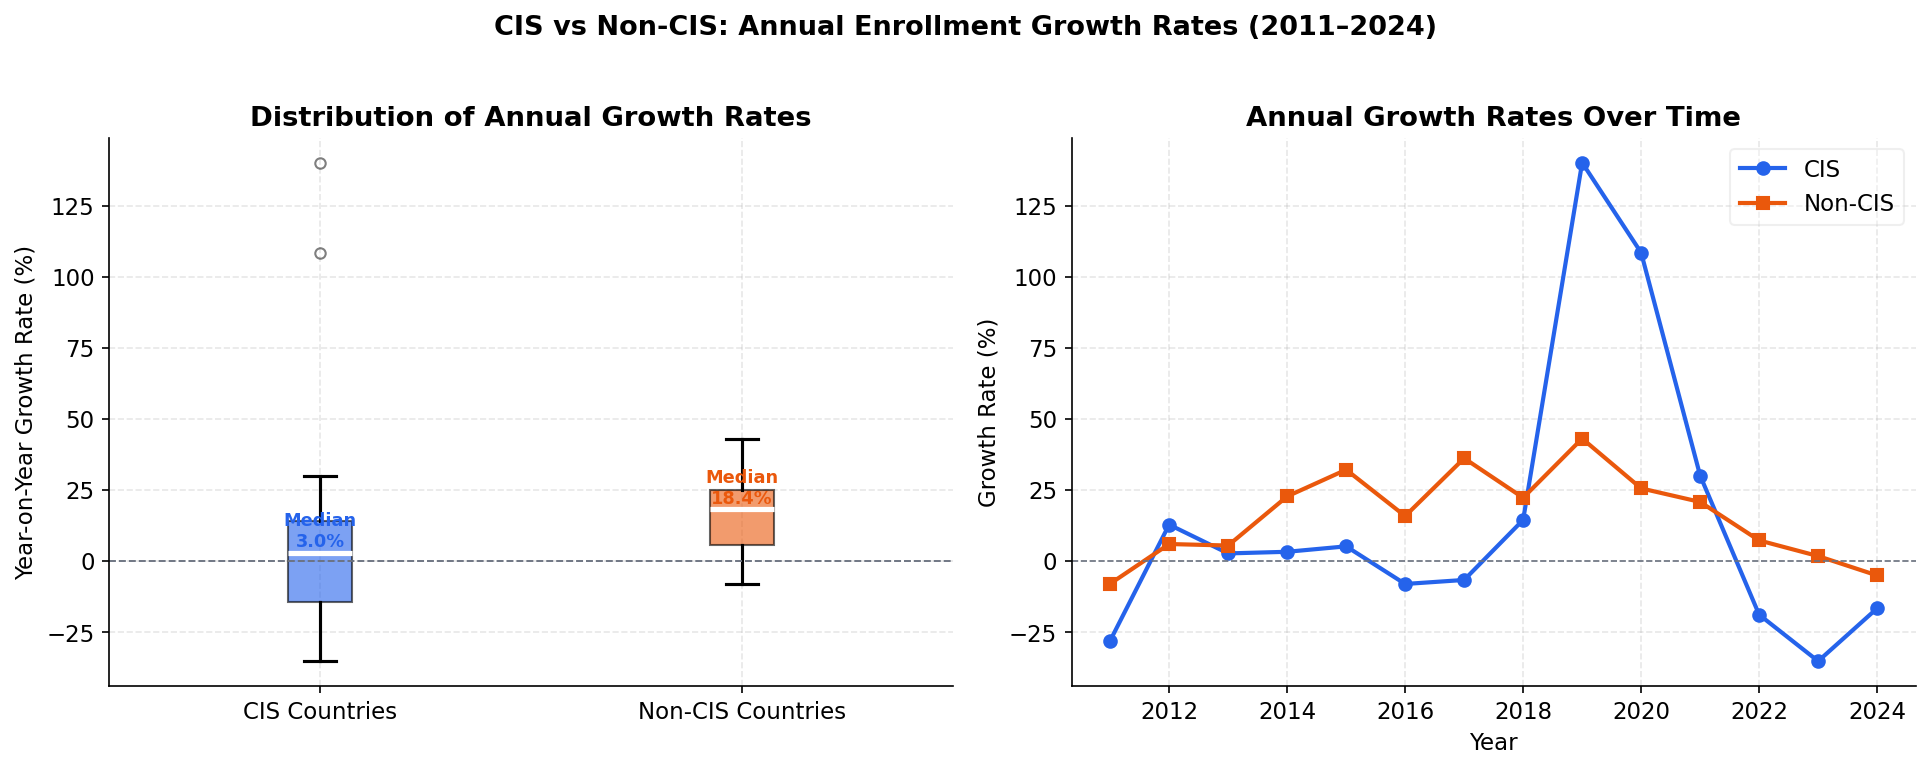

Fig 9 saved.


In [12]:
cis_gr     = students_df['CIS'].pct_change().dropna().replace([np.inf,-np.inf],np.nan).dropna()*100
ncis_gr    = students_df['Non_CIS'].pct_change().dropna().replace([np.inf,-np.inf],np.nan).dropna()*100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
ax = axes[0]
bp = ax.boxplot([cis_gr.values, ncis_gr.values],
                labels=['CIS Countries','Non-CIS Countries'],
                patch_artist=True, notch=False,
                boxprops=dict(facecolor=BLUE, alpha=0.6),
                medianprops=dict(color='white', linewidth=2.5),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5),
                flierprops=dict(marker='o', markersize=5, alpha=0.5))
bp['boxes'][1].set_facecolor(ORANGE)
ax.axhline(0, color=GRAY, linestyle='--', linewidth=0.9)
ax.set_ylabel('Year-on-Year Growth Rate (%)')
ax.set_title('Distribution of Annual Growth Rates', fontweight='bold')

# Annotate medians
for i, (vals, col) in enumerate([(cis_gr, BLUE),(ncis_gr, ORANGE)], 1):
    ax.text(i, vals.median()+2, f'Median\n{vals.median():.1f}%', ha='center', fontsize=8.5, color=col, fontweight='bold')

# Line chart of growth rates over time
ax2 = axes[1]
ax2.plot(students_df['Year'][1:], cis_gr.values,  'o-', color=BLUE,   linewidth=2, label='CIS')
ax2.plot(students_df['Year'][1:], ncis_gr.values, 's-', color=ORANGE, linewidth=2, label='Non-CIS')
ax2.axhline(0, color=GRAY, linestyle='--', linewidth=0.8)
ax2.set_xlabel('Year')
ax2.set_ylabel('Growth Rate (%)')
ax2.set_title('Annual Growth Rates Over Time', fontweight='bold')
ax2.legend(framealpha=0.3)

plt.suptitle('CIS vs Non-CIS: Annual Enrollment Growth Rates (2011–2024)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../photo/fig9_growth_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 9 saved.')

## 11. Figure 10 — Country Heatmap (Enrollment by Year)

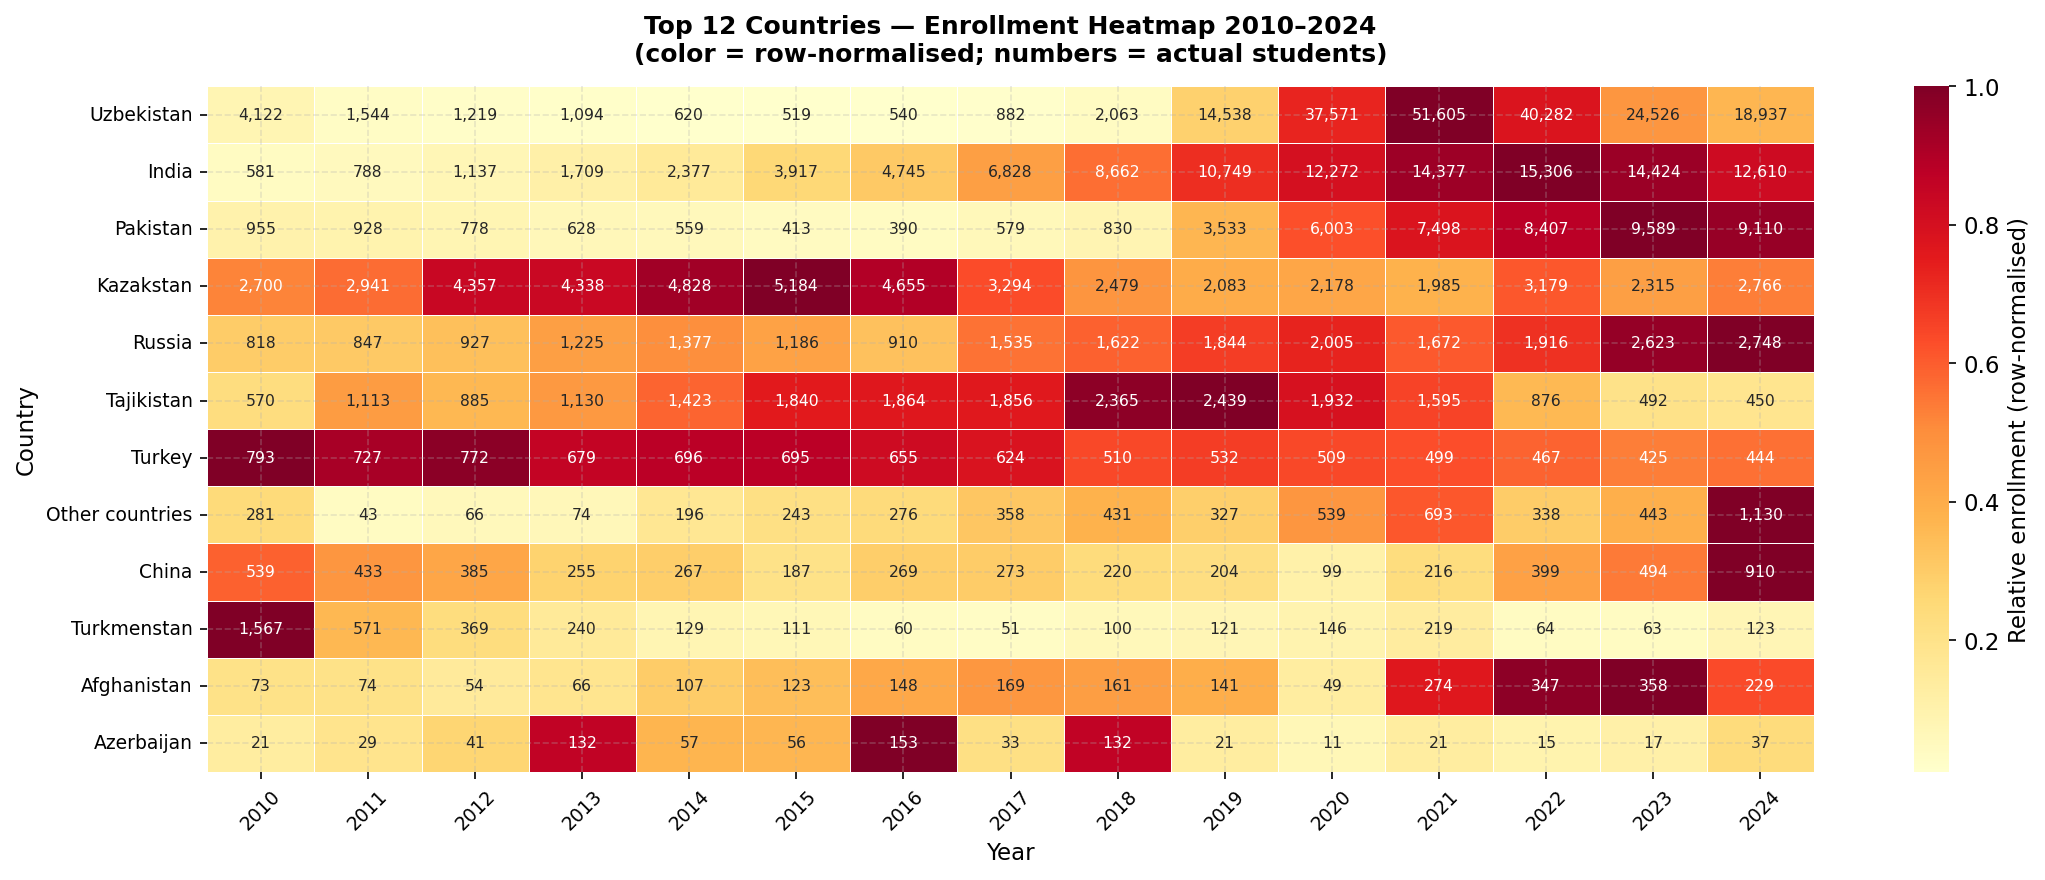

Fig 10 saved.


In [13]:
totals3 = countries_df.copy()
totals3['Total'] = totals3[year_cols].sum(axis=1)
top12 = totals3.sort_values('Total', ascending=False).head(12)

heat_data = top12.set_index('Country')[year_cols].astype(float)
# Normalise each country row (0–1) so small countries are still visible
heat_norm = heat_data.div(heat_data.max(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(heat_norm, cmap='YlOrRd', ax=ax, linewidths=0.4, linecolor='white',
            cbar_kws={'label':'Relative enrollment (row-normalised)'},
            annot=heat_data.applymap(lambda v: f'{int(v):,}' if not np.isnan(v) else ''),
            fmt='', annot_kws={'size':7.5})
ax.set_xlabel('Year')
ax.set_title('Top 12 Countries — Enrollment Heatmap 2010–2024\n(color = row-normalised; numbers = actual students)',
             fontsize=12, fontweight='bold', pad=12)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig('../photo/fig10_country_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 10 saved.')